🔬 ANALYSE COMPARATIVE AVEC SÉLECTION SPÉCIFIQUE PAR MODÈLE

🚀 SÉLECTION DE FEATURES SPÉCIFIQUE PAR MODÈLE

🔥 RECUIT SIMULÉ - Sélection Features KNN
🎯 Solution initiale: 10 features, score: 0.695
🔥 Itération 1: 11 features, score: 0.967
🔥 Itération 2: 11 features, score: 0.967
🔥 Itération 3: 11 features, score: 0.968
🔥 Itération 5: 11 features, score: 0.982
🔥 Itération 7: 11 features, score: 0.985
🔥 Itération 13: 11 features, score: 0.987

🏆 MEILLEURES FEATURES POUR KNN:
   Nombre de features: 11
   Features indices: [ 0 15 23  9 27 37 29 36  2 22 38]
   Validation Score: 0.987

🔥 RECUIT SIMULÉ - Sélection Features Decision Tree
🎯 Solution initiale: 10 features, score: 0.781
🔥 Itération 1: 11 features, score: 0.781
🔥 Itération 2: 10 features, score: 0.784
🔥 Itération 3: 11 features, score: 0.808
🔥 Itération 4: 11 features, score: 0.842

🏆 MEILLEURES FEATURES POUR DECISION TREE:
   Nombre de features: 11
   Features indices: [33 34 30 22 28 15 29 19 32  4  1]
   Validation Score: 0.842



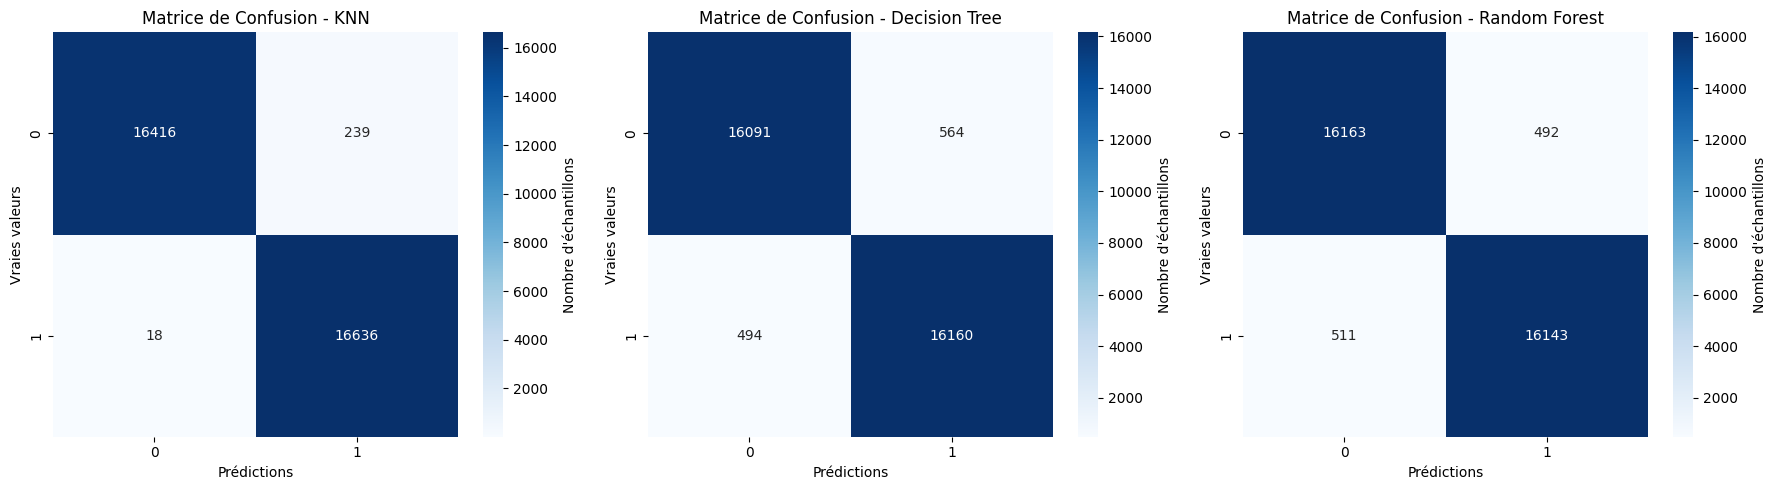


📈 COURBES ROC


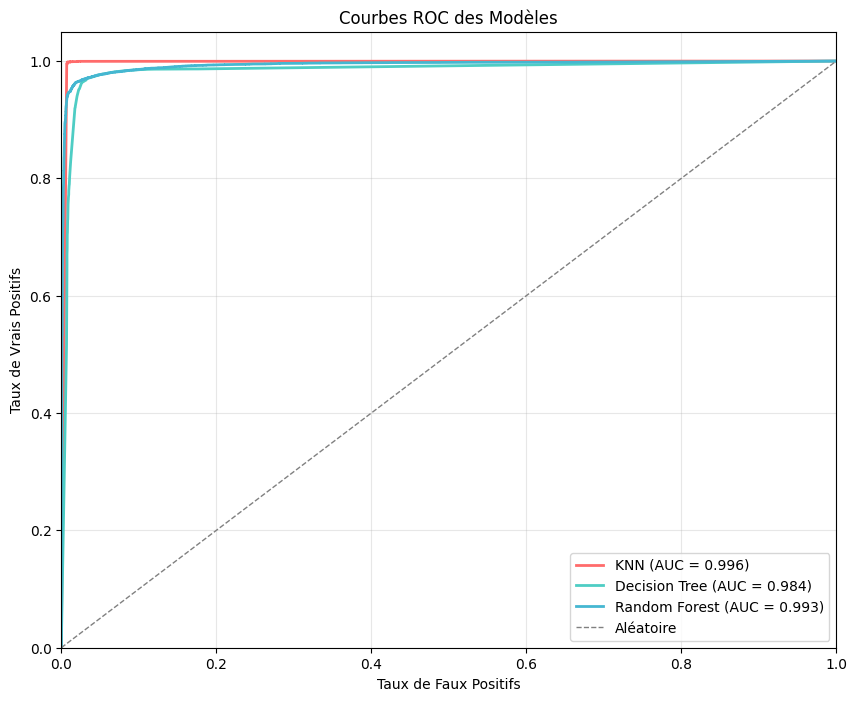


📊 COMPARAISON VISUELLE DES MÉTRIQUES


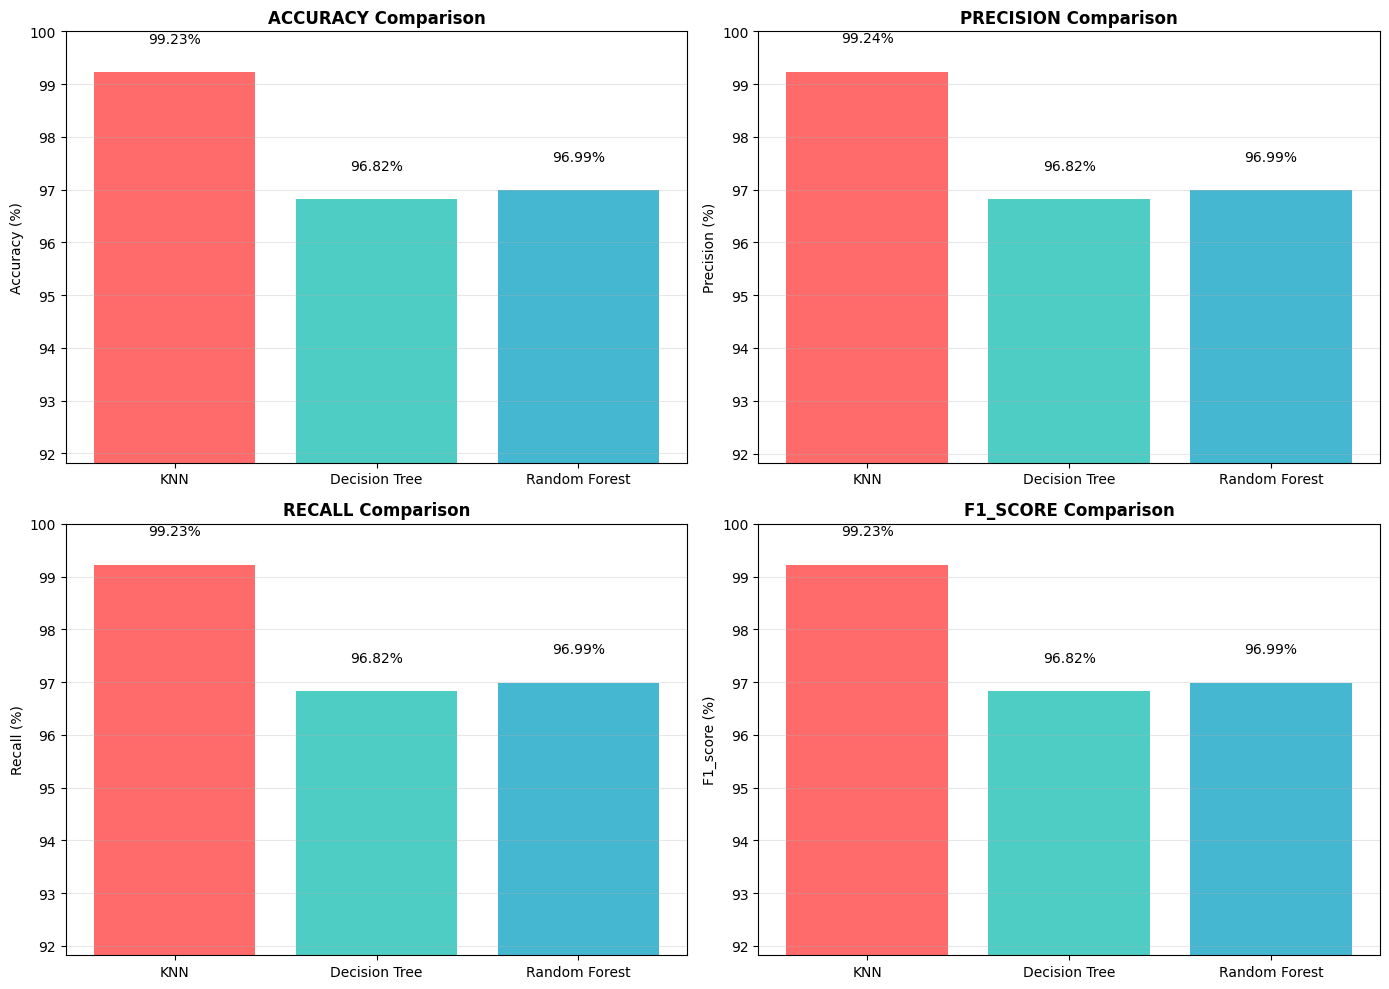


📈 VISUALISATION DES RÉSULTATS


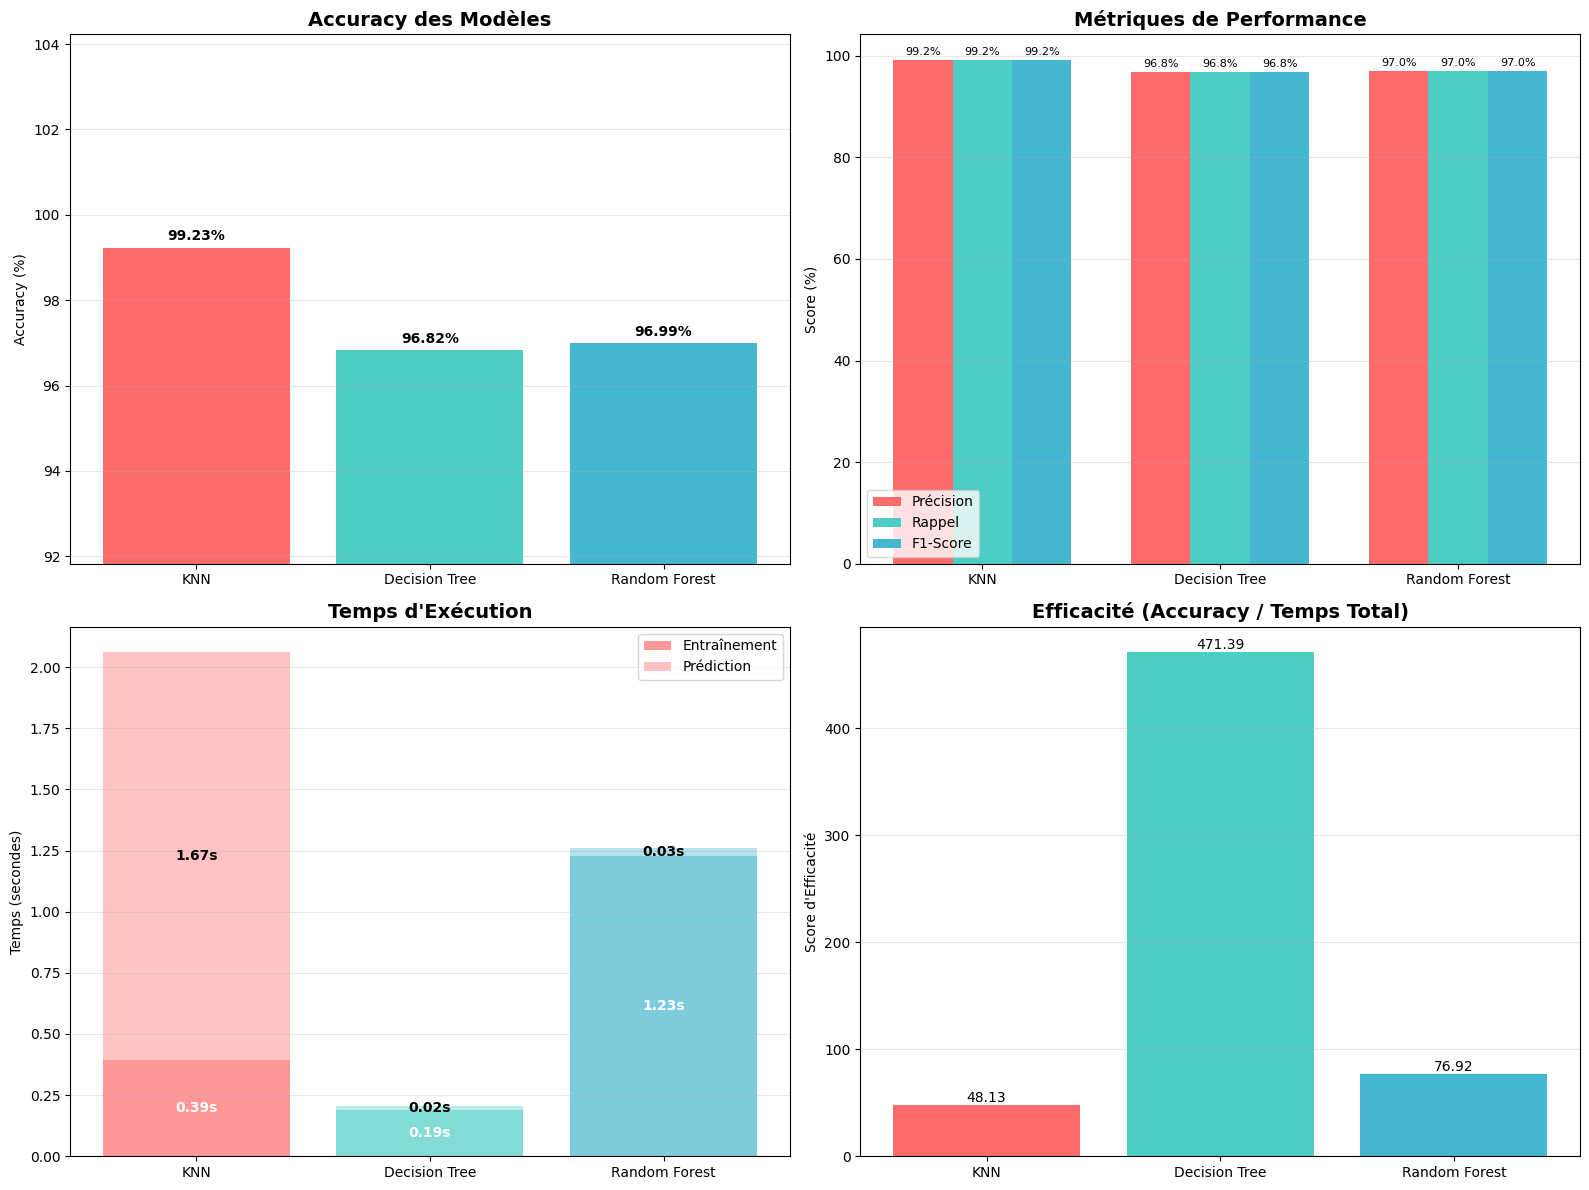


🔍 ANALYSE DÉTAILLÉE PAR MODÈLE

📊 KNN:
   ✅ Accuracy: 99.23%
   🎯 Precision: 99.24%
   📈 Recall: 99.23%
   ⚖️  F1-Score: 99.23%
   📊 ROC-AUC: 0.996
   📈 Average Precision: 0.993
   ⏱️  Temps entraînement: 0.39s
   ⏱️  Temps prédiction: 1.67s
   🔢 Nombre de features: 11
   ⚙️  Paramètres optimaux: {'n_neighbors': np.int64(5), 'weights': np.str_('distance'), 'metric': np.str_('manhattan')}

📊 DECISION TREE:
   ✅ Accuracy: 96.82%
   🎯 Precision: 96.82%
   📈 Recall: 96.82%
   ⚖️  F1-Score: 96.82%
   📊 ROC-AUC: 0.984
   📈 Average Precision: 0.979
   ⏱️  Temps entraînement: 0.19s
   ⏱️  Temps prédiction: 0.02s
   🔢 Nombre de features: 11
   ⚙️  Paramètres optimaux: {'max_depth': np.int64(20), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(2), 'criterion': np.str_('gini')}

📊 RANDOM FOREST:
   ✅ Accuracy: 96.99%
   🎯 Precision: 96.99%
   📈 Recall: 96.99%
   ⚖️  F1-Score: 96.99%
   📊 ROC-AUC: 0.993
   📈 Average Precision: 0.994
   ⏱️  Temps entraînement: 1.23s
   ⏱️  Temps pré

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import time
import math
from collections import defaultdict

# ============== RECUIT SIMULÉ POUR L'OPTIMISATION ==============

def simulated_annealing_feature_selection_knn(X_train, y_train, X_val, y_val, n_iterations=15, initial_temp=80):
    """Sélection de features OPTIMISÉE pour KNN"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Sélection Features KNN")
    print("="*60)
    
    n_features = X_train.shape[1]
    
    def evaluate_features(selected_indices):
        if len(selected_indices) == 0:
            return 0
        
        X_train_sub = X_train[:, selected_indices]
        X_val_sub = X_val[:, selected_indices]
        
        # Évaluation avec KNN (le modèle cible)
        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_train_sub, y_train)
        score = model.score(X_val_sub, y_val)
        
        # Pénalités adaptées à KNN
        n_selected = len(selected_indices)
        if n_selected < 8:  # KNN a besoin de plus de features
            score -= (8 - n_selected) * 0.03
        elif n_selected > 25:  # KNN sensible au "curse of dimensionality"
            score -= (n_selected - 25) * 0.04
            
        return max(0, score)
    
    current_solution = np.random.choice(n_features, size=np.random.randint(10, 16), replace=False)
    current_score = evaluate_features(current_solution)
    best_solution = current_solution.copy()
    best_score = current_score
    
    print(f"🎯 Solution initiale: {len(current_solution)} features, score: {current_score:.3f}")
    
    temperature = initial_temp
    for iteration in range(n_iterations):
        neighbor_solution = current_solution.copy()
        operation = np.random.choice(['add', 'remove', 'replace'])
        
        if operation == 'add' and len(neighbor_solution) < n_features:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                new_feature = np.random.choice(available_features)
                neighbor_solution = np.append(neighbor_solution, new_feature)
                
        elif operation == 'remove' and len(neighbor_solution) > 8:
            remove_idx = np.random.randint(len(neighbor_solution))
            neighbor_solution = np.delete(neighbor_solution, remove_idx)
            
        elif operation == 'replace' and len(neighbor_solution) > 0:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                remove_idx = np.random.randint(len(neighbor_solution))
                new_feature = np.random.choice(available_features)
                neighbor_solution[remove_idx] = new_feature
        
        neighbor_score = evaluate_features(neighbor_solution)
        
        if neighbor_score > current_score:
            current_solution = neighbor_solution
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_solution = neighbor_solution
                current_score = neighbor_score
        
        if current_score > best_score:
            best_solution = current_solution.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {len(best_solution)} features, score: {best_score:.3f}")
        
        temperature = initial_temp * (0.95 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURES FEATURES POUR KNN:")
    print(f"   Nombre de features: {len(best_solution)}")
    print(f"   Features indices: {best_solution}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_solution

def simulated_annealing_feature_selection_tree(X_train, y_train, X_val, y_val, n_iterations=15, initial_temp=80):
    """Sélection de features OPTIMISÉE pour Decision Tree"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Sélection Features Decision Tree")
    print("="*60)
    
    n_features = X_train.shape[1]
    
    def evaluate_features(selected_indices):
        if len(selected_indices) == 0:
            return 0
        
        X_train_sub = X_train[:, selected_indices]
        X_val_sub = X_val[:, selected_indices]
        
        # Évaluation avec Decision Tree (le modèle cible)
        model = DecisionTreeClassifier(max_depth=5, random_state=42)
        model.fit(X_train_sub, y_train)
        score = model.score(X_val_sub, y_val)
        
        # Pénalités adaptées aux arbres
        n_selected = len(selected_indices)
        if n_selected < 5:  # Arbres fonctionnent bien avec peu de features
            score -= (5 - n_selected) * 0.05
        elif n_selected > 20:  # Trop de features = arbre trop complexe
            score -= (n_selected - 20) * 0.03
            
        return max(0, score)
    
    current_solution = np.random.choice(n_features, size=np.random.randint(8, 12), replace=False)
    current_score = evaluate_features(current_solution)
    best_solution = current_solution.copy()
    best_score = current_score
    
    print(f"🎯 Solution initiale: {len(current_solution)} features, score: {current_score:.3f}")
    
    temperature = initial_temp
    for iteration in range(n_iterations):
        neighbor_solution = current_solution.copy()
        operation = np.random.choice(['add', 'remove', 'replace'])
        
        if operation == 'add' and len(neighbor_solution) < n_features:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                new_feature = np.random.choice(available_features)
                neighbor_solution = np.append(neighbor_solution, new_feature)
                
        elif operation == 'remove' and len(neighbor_solution) > 5:
            remove_idx = np.random.randint(len(neighbor_solution))
            neighbor_solution = np.delete(neighbor_solution, remove_idx)
            
        elif operation == 'replace' and len(neighbor_solution) > 0:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                remove_idx = np.random.randint(len(neighbor_solution))
                new_feature = np.random.choice(available_features)
                neighbor_solution[remove_idx] = new_feature
        
        neighbor_score = evaluate_features(neighbor_solution)
        
        if neighbor_score > current_score:
            current_solution = neighbor_solution
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_solution = neighbor_solution
                current_score = neighbor_score
        
        if current_score > best_score:
            best_solution = current_solution.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {len(best_solution)} features, score: {best_score:.3f}")
        
        temperature = initial_temp * (0.95 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURES FEATURES POUR DECISION TREE:")
    print(f"   Nombre de features: {len(best_solution)}")
    print(f"   Features indices: {best_solution}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_solution

def simulated_annealing_feature_selection_forest(X_train, y_train, X_val, y_val, n_iterations=15, initial_temp=80):
    """Sélection de features OPTIMISÉE pour Random Forest"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Sélection Features Random Forest")
    print("="*60)
    
    n_features = X_train.shape[1]
    
    def evaluate_features(selected_indices):
        if len(selected_indices) == 0:
            return 0
        
        X_train_sub = X_train[:, selected_indices]
        X_val_sub = X_val[:, selected_indices]
        
        # Évaluation avec Random Forest (le modèle cible)
        model = RandomForestClassifier(n_estimators=5, max_depth=5, random_state=42)
        model.fit(X_train_sub, y_train)
        score = model.score(X_val_sub, y_val)
        
        # Pénalités adaptées aux forêts
        n_selected = len(selected_indices)
        if n_selected < 10:  # Forêts aiment avoir plusieurs features pour diversité
            score -= (10 - n_selected) * 0.04
        elif n_selected > 30:  # Mais pas trop non plus
            score -= (n_selected - 30) * 0.02
            
        return max(0, score)
    
    current_solution = np.random.choice(n_features, size=np.random.randint(12, 18), replace=False)
    current_score = evaluate_features(current_solution)
    best_solution = current_solution.copy()
    best_score = current_score
    
    print(f"🎯 Solution initiale: {len(current_solution)} features, score: {current_score:.3f}")
    
    temperature = initial_temp
    for iteration in range(n_iterations):
        neighbor_solution = current_solution.copy()
        operation = np.random.choice(['add', 'remove', 'replace'])
        
        if operation == 'add' and len(neighbor_solution) < n_features:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                new_feature = np.random.choice(available_features)
                neighbor_solution = np.append(neighbor_solution, new_feature)
                
        elif operation == 'remove' and len(neighbor_solution) > 10:
            remove_idx = np.random.randint(len(neighbor_solution))
            neighbor_solution = np.delete(neighbor_solution, remove_idx)
            
        elif operation == 'replace' and len(neighbor_solution) > 0:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                remove_idx = np.random.randint(len(neighbor_solution))
                new_feature = np.random.choice(available_features)
                neighbor_solution[remove_idx] = new_feature
        
        neighbor_score = evaluate_features(neighbor_solution)
        
        if neighbor_score > current_score:
            current_solution = neighbor_solution
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_solution = neighbor_solution
                current_score = neighbor_score
        
        if current_score > best_score:
            best_solution = current_solution.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {len(best_solution)} features, score: {best_score:.3f}")
        
        temperature = initial_temp * (0.95 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURES FEATURES POUR RANDOM FOREST:")
    print(f"   Nombre de features: {len(best_solution)}")
    print(f"   Features indices: {best_solution}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_solution

def simulated_annealing_knn(X_train, y_train, X_val, y_val, n_iterations=15, initial_temp=30):
    """Optimisation KNN avec bornes cohérentes"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Optimisation KNN")
    print("="*60)
    
    param_space = {
        'n_neighbors': [3, 5, 7, 9, 11],  # Garde raisonnable
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']  # Simplifié
    }
    
    def evaluate_params(params):
        """Évalue un ensemble de paramètres"""
        try:
            model = KNeighborsClassifier(**params)
            model.fit(X_train, y_train)
            return model.score(X_val, y_val)
        except:
            return 0
    
    current_params = {
        'n_neighbors': np.random.choice(param_space['n_neighbors']),
        'weights': np.random.choice(param_space['weights']),
        'metric': np.random.choice(param_space['metric'])
    }
    current_score = evaluate_params(current_params)
    
    best_params = current_params.copy()
    best_score = current_score
    
    print(f"🎯 Paramètres initiaux: {current_params}, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        neighbor_params = current_params.copy()
        param_to_change = np.random.choice(list(param_space.keys()))
        neighbor_params[param_to_change] = np.random.choice(param_space[param_to_change])
        
        neighbor_score = evaluate_params(neighbor_params)
        
        if neighbor_score > current_score:
            current_params = neighbor_params
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_params = neighbor_params
                current_score = neighbor_score
        
        if current_score > best_score:
            best_params = current_params.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {best_params}, score: {best_score:.3f}")
        
        temperature = initial_temp * (0.9 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURS PARAMÈTRES KNN:")
    print(f"   n_neighbors: {best_params['n_neighbors']}")
    print(f"   weights: {best_params['weights']}")
    print(f"   metric: {best_params['metric']}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_params, best_score

def simulated_annealing_tree(X_train, y_train, X_val, y_val, n_iterations=15, initial_temp=30):
    """Optimisation Decision Tree avec les mêmes bornes que la version from scratch"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Optimisation Decision Tree")
    print("="*60)
    
    param_space = {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2],
        'criterion': ['gini', 'entropy']
    }
    
    def evaluate_params(params):
        """Évalue un ensemble de paramètres"""
        model = DecisionTreeClassifier(**params, random_state=42)
        model.fit(X_train, y_train)
        return model.score(X_val, y_val)
    
    current_params = {
        'max_depth': np.random.choice(param_space['max_depth']),
        'min_samples_split': np.random.choice(param_space['min_samples_split']),
        'min_samples_leaf': np.random.choice(param_space['min_samples_leaf']),
        'criterion': np.random.choice(param_space['criterion'])
    }
    current_score = evaluate_params(current_params)
    
    best_params = current_params.copy()
    best_score = current_score
    
    print(f"🎯 Paramètres initiaux: {current_params}, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        neighbor_params = current_params.copy()
        param_to_change = np.random.choice(list(param_space.keys()))
        neighbor_params[param_to_change] = np.random.choice(param_space[param_to_change])
        
        neighbor_score = evaluate_params(neighbor_params)
        
        if neighbor_score > current_score:
            current_params = neighbor_params
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_params = neighbor_params
                current_score = neighbor_score
        
        if current_score > best_score:
            best_params = current_params.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {best_params}, score: {best_score:.3f}")
        
        temperature = initial_temp * (0.9 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURS PARAMÈTRES DECISION TREE:")
    print(f"   max_depth: {best_params['max_depth']}")
    print(f"   min_samples_split: {best_params['min_samples_split']}")
    print(f"   min_samples_leaf: {best_params['min_samples_leaf']}")
    print(f"   criterion: {best_params['criterion']}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_params, best_score

def simulated_annealing_forest(X_train, y_train, X_val, y_val, n_iterations=15, initial_temp=30):
    """Optimisation Random Forest avec les mêmes bornes que la version from scratch"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Optimisation Random Forest")
    print("="*60)
    
    param_space = {
        'n_estimators': [5, 10, 15, 20],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2],
        'max_features': [None, 'sqrt']
    }
    
    def evaluate_params(params):
        """Évalue un ensemble de paramètres"""
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        return model.score(X_val, y_val)
    
    current_params = {
        'n_estimators': np.random.choice(param_space['n_estimators']),
        'max_depth': np.random.choice(param_space['max_depth']),
        'min_samples_split': np.random.choice(param_space['min_samples_split']),
        'min_samples_leaf': np.random.choice(param_space['min_samples_leaf']),
        'max_features': np.random.choice(param_space['max_features'])
    }
    current_score = evaluate_params(current_params)
    
    best_params = current_params.copy()
    best_score = current_score
    
    print(f"🎯 Paramètres initiaux: {current_params}, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        neighbor_params = current_params.copy()
        param_to_change = np.random.choice(list(param_space.keys()))
        neighbor_params[param_to_change] = np.random.choice(param_space[param_to_change])
        
        neighbor_score = evaluate_params(neighbor_params)
        
        if neighbor_score > current_score:
            current_params = neighbor_params
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_params = neighbor_params
                current_score = neighbor_score
        
        if current_score > best_score:
            best_params = current_params.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {best_params}, score: {best_score:.3f}")
        
        temperature = initial_temp * (0.9 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURS PARAMÈTRES RANDOM FOREST:")
    print(f"   n_estimators: {best_params['n_estimators']}")
    print(f"   max_depth: {best_params['max_depth']}")
    print(f"   min_samples_split: {best_params['min_samples_split']}")
    print(f"   min_samples_leaf: {best_params['min_samples_leaf']}")
    print(f"   max_features: {best_params['max_features']}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_params, best_score

def calculate_all_metrics(y_true, y_pred, y_proba=None):
    """Calcule toutes les métriques d'évaluation"""
    metrics = {}
    
    # Métriques de base
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Métriques par classe (pour classification binaire ou multi-classe)
    if len(np.unique(y_true)) == 2:
        # Classification binaire
        metrics['precision_class_0'] = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
        metrics['precision_class_1'] = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        metrics['recall_class_0'] = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
        metrics['recall_class_1'] = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        metrics['f1_class_0'] = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
        metrics['f1_class_1'] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        
        # Métriques basées sur les probabilités si disponibles
        if y_proba is not None:
            try:
                metrics['roc_auc'] = roc_auc_score(y_true, y_proba[:, 1])
                metrics['avg_precision'] = average_precision_score(y_true, y_proba[:, 1])
            except:
                metrics['roc_auc'] = 0.0
                metrics['avg_precision'] = 0.0
    
    return metrics

def plot_confusion_matrices(y_test_list, y_pred_list, model_names):
    """Affiche les matrices de confusion pour tous les modèles"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (y_test, y_pred, model_name, ax) in enumerate(zip(y_test_list, y_pred_list, model_names, axes)):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                   cbar_kws={'label': 'Nombre d\'échantillons'})
        ax.set_xlabel('Prédictions')
        ax.set_ylabel('Vraies valeurs')
        ax.set_title(f'Matrice de Confusion - {model_name}')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_test_list, y_proba_list, model_names):
    """Affiche les courbes ROC pour tous les modèles (si classification binaire)"""
    if y_proba_list[0] is None:
        return
    
    plt.figure(figsize=(10, 8))
    
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
    
    for y_test, y_proba, model_name, color in zip(y_test_list, y_proba_list, model_names, colors):
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        
        plt.plot(fpr, tpr, color=color, lw=2, 
                label=f'{model_name} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aléatoire')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs')
    plt.ylabel('Taux de Vrais Positifs')
    plt.title('Courbes ROC des Modèles')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_metric_comparison(results):
    """Affiche une comparaison visuelle de toutes les métriques"""
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        models = list(results.keys())
        values = [results[model]['metrics'][metric] * 100 for model in models]
        
        bars = ax.bar(models, values, color=colors)
        ax.set_title(f'{metric.upper()} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{metric.capitalize()} (%)')
        ax.set_ylim([min(values) - 5, 100])
        
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{value:.2f}%', ha='center', va='bottom', fontsize=10)
        
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('metric_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============== PROGRAMME PRINCIPAL ==============

print("="*80)
print("🔬 ANALYSE COMPARATIVE AVEC SÉLECTION SPÉCIFIQUE PAR MODÈLE")
print("="*80)

# Chargement et préparation des données
df = pd.read_csv("balanced_dataset_under.csv")
columns_to_exclude = ['acq_date','X','Y','confidence']
feature_columns = [col for col in df.columns if col not in columns_to_exclude and col != 'fire']

X = df[feature_columns].values
Y = df['fire'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.20, random_state=42, stratify=Y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

# SÉLECTION DE FEATURES SPÉCIFIQUE À CHAQUE MODÈLE
print("\n" + "="*80)
print("🚀 SÉLECTION DE FEATURES SPÉCIFIQUE PAR MODÈLE")
print("="*80)

start_time_total = time.time()

# 1. KNN - Sélection spécifique
selected_indices_knn = simulated_annealing_feature_selection_knn(
    X_train, y_train, X_val, y_val, 
    n_iterations=15, initial_temp=80
)
X_train_knn = X_train[:, selected_indices_knn]
X_val_knn = X_val[:, selected_indices_knn]
X_test_knn = X_test[:, selected_indices_knn]

# 2. Decision Tree - Sélection spécifique  
selected_indices_tree = simulated_annealing_feature_selection_tree(
    X_train, y_train, X_val, y_val,
    n_iterations=15, initial_temp=80
)
X_train_tree = X_train[:, selected_indices_tree]
X_val_tree = X_val[:, selected_indices_tree]
X_test_tree = X_test[:, selected_indices_tree]

# 3. Random Forest - Sélection spécifique
selected_indices_forest = simulated_annealing_feature_selection_forest(
    X_train, y_train, X_val, y_val,
    n_iterations=15, initial_temp=80
)
X_train_forest = X_train[:, selected_indices_forest]
X_val_forest = X_val[:, selected_indices_forest]
X_test_forest = X_test[:, selected_indices_forest]

print(f"\n📊 RÉSUMÉ DES SÉLECTIONS DE FEATURES:")
print(f"🔍 KNN: {len(selected_indices_knn)} features")
print(f"🌳 Decision Tree: {len(selected_indices_tree)} features") 
print(f"🌲 Random Forest: {len(selected_indices_forest)} features")

# 2. Optimisation des modèles
print("\n" + "="*80)
print("🧪 OPTIMISATION DES MODÈLES")
print("="*80)

# KNN - avec ses propres features
knn_params, knn_score = simulated_annealing_knn(
    X_train_knn, y_train, X_val_knn, y_val,
    n_iterations=12,
    initial_temp=25
)

# Decision Tree - avec ses propres features  
tree_params, tree_score = simulated_annealing_tree(
    X_train_tree, y_train, X_val_tree, y_val,
    n_iterations=12,
    initial_temp=25
)

# Random Forest - avec ses propres features
forest_params, forest_score = simulated_annealing_forest(
    X_train_forest, y_train, X_val_forest, y_val,
    n_iterations=12,
    initial_temp=25
)

optimization_time = time.time() - start_time_total
print(f"⏱️ Temps d'optimisation total: {optimization_time:.2f}s")

# ============== SECTION ENTRAÎNEMENT ET ÉVALUATION ==============

print("\n" + "="*80)
print("🎯 ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES")
print("="*80)

results = {}
all_y_pred = []
all_y_test = []
all_y_proba = []

# KNN avec ses features
print("\n🔍 Entraînement KNN...")
start_time = time.time()
knn_model = KNeighborsClassifier(**knn_params)
knn_model.fit(X_train_knn, y_train)
knn_train_time = time.time() - start_time

start_time = time.time()
y_pred_knn = knn_model.predict(X_test_knn)
knn_pred_time = time.time() - start_time

# Probabilités pour KNN (approximées)
y_proba_knn = knn_model.predict_proba(X_test_knn)

# Calcul de toutes les métriques pour KNN
knn_metrics = calculate_all_metrics(y_test, y_pred_knn, y_proba_knn)
knn_accuracy = knn_metrics['accuracy']

results['KNN'] = {
    'accuracy': knn_accuracy,
    'train_time': knn_train_time,
    'pred_time': knn_pred_time,
    'params': knn_params,
    'features_count': X_train_knn.shape[1],
    'metrics': knn_metrics  # Ajout de toutes les métriques
}

all_y_pred.append(y_pred_knn)
all_y_test.append(y_test)
all_y_proba.append(y_proba_knn)

# Decision Tree avec ses features
print("🌳 Entraînement Decision Tree...")
start_time = time.time()
tree_model = DecisionTreeClassifier(**tree_params, random_state=42)
tree_model.fit(X_train_tree, y_train)
tree_train_time = time.time() - start_time

start_time = time.time()
y_pred_tree = tree_model.predict(X_test_tree)
tree_pred_time = time.time() - start_time

# Probabilités pour Decision Tree
y_proba_tree = tree_model.predict_proba(X_test_tree)

# Calcul de toutes les métriques pour Decision Tree
tree_metrics = calculate_all_metrics(y_test, y_pred_tree, y_proba_tree)
tree_accuracy = tree_metrics['accuracy']

results['Decision Tree'] = {
    'accuracy': tree_accuracy,
    'train_time': tree_train_time,
    'pred_time': tree_pred_time,
    'params': tree_params,
    'features_count': X_train_tree.shape[1],
    'metrics': tree_metrics  # Ajout de toutes les métriques
}

all_y_pred.append(y_pred_tree)
all_y_test.append(y_test)
all_y_proba.append(y_proba_tree)

# Random Forest avec ses features
print("🌲 Entraînement Random Forest...")
start_time = time.time()
forest_model = RandomForestClassifier(**forest_params, random_state=42, n_jobs=-1)
forest_model.fit(X_train_forest, y_train)
forest_train_time = time.time() - start_time

start_time = time.time()
y_pred_forest = forest_model.predict(X_test_forest)
forest_pred_time = time.time() - start_time

# Probabilités pour Random Forest
y_proba_forest = forest_model.predict_proba(X_test_forest)

# Calcul de toutes les métriques pour Random Forest
forest_metrics = calculate_all_metrics(y_test, y_pred_forest, y_proba_forest)
forest_accuracy = forest_metrics['accuracy']

results['Random Forest'] = {
    'accuracy': forest_accuracy,
    'train_time': forest_train_time,
    'pred_time': forest_pred_time,
    'params': forest_params,
    'features_count': X_train_forest.shape[1],
    'metrics': forest_metrics  # Ajout de toutes les métriques
}

all_y_pred.append(y_pred_forest)
all_y_test.append(y_test)
all_y_proba.append(y_proba_forest)

# ============== VISUALISATIONS ET ANALYSES ==============

# 1. Tableau comparatif détaillé
print("\n" + "="*120)
print("🏆 TABLEAU COMPARATIF DÉTAILLÉ DES MODÈLES")
print("="*120)
print(f"{'Modèle':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Temps Ent.':<10} {'Temps Pred.':<10} {'Features':<8}")
print("-" * 120)

for model_name, metrics in results.items():
    model_metrics = metrics['metrics']
    print(f"{model_name:<15} "
          f"{model_metrics['accuracy']*100:<9.2f}% "
          f"{model_metrics['precision']*100:<9.2f}% "
          f"{model_metrics['recall']*100:<9.2f}% "
          f"{model_metrics['f1_score']*100:<9.2f}% "
          f"{metrics['train_time']:<9.2f}s "
          f"{metrics['pred_time']:<9.2f}s "
          f"{metrics['features_count']:<8}")

print("=" * 120)

# 2. Tableau détaillé par classe (si classification binaire)
if 'precision_class_0' in results['KNN']['metrics']:
    print("\n" + "="*100)
    print("📊 MÉTRIQUES PAR CLASSE (Classification Binaire)")
    print("="*100)
    print(f"{'Modèle':<15} {'Précision Classe 0':<18} {'Précision Classe 1':<18} {'Rappel Classe 0':<16} {'Rappel Classe 1':<16}")
    print("-" * 100)
    
    for model_name, metrics in results.items():
        model_metrics = metrics['metrics']
        print(f"{model_name:<15} "
              f"{model_metrics['precision_class_0']*100:<17.2f}% "
              f"{model_metrics['precision_class_1']*100:<17.2f}% "
              f"{model_metrics['recall_class_0']*100:<15.2f}% "
              f"{model_metrics['recall_class_1']*100:<15.2f}%")
    
    print("=" * 100)

# 3. Visualisation des matrices de confusion
print("\n📊 VISUALISATION DES MATRICES DE CONFUSION")
plot_confusion_matrices(all_y_test, all_y_pred, ['KNN', 'Decision Tree', 'Random Forest'])

# 4. Courbes ROC (si classification binaire et probabilités disponibles)
if all_y_proba[0] is not None:
    print("\n📈 COURBES ROC")
    plot_roc_curves(all_y_test, all_y_proba, ['KNN', 'Decision Tree', 'Random Forest'])

# 5. Comparaison visuelle des métriques
print("\n📊 COMPARAISON VISUELLE DES MÉTRIQUES")
plot_metric_comparison(results)

# 6. Graphiques de performance supplémentaires
print("\n📈 VISUALISATION DES RÉSULTATS")
print("="*80)

models = list(results.keys())
accuracies = [results[model]['metrics']['accuracy'] * 100 for model in models]
train_times = [results[model]['train_time'] for model in models]
pred_times = [results[model]['pred_time'] for model in models]
precisions = [results[model]['metrics']['precision'] * 100 for model in models]
recalls = [results[model]['metrics']['recall'] * 100 for model in models]
f1_scores = [results[model]['metrics']['f1_score'] * 100 for model in models]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy
bars1 = ax1.bar(models, accuracies, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax1.set_title('Accuracy des Modèles', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(min(accuracies) - 5, max(accuracies) + 5)
for bar, accuracy in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{accuracy:.2f}%', ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Métriques principales (Precision, Recall, F1)
x = np.arange(len(models))
width = 0.25
bars2_1 = ax2.bar(x - width, precisions, width, label='Précision', color='#ff6b6b')
bars2_2 = ax2.bar(x, recalls, width, label='Rappel', color='#4ecdc4')
bars2_3 = ax2.bar(x + width, f1_scores, width, label='F1-Score', color='#45b7d1')
ax2.set_title('Métriques de Performance', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for bars in [bars2_1, bars2_2, bars2_3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# Temps d'exécution
bars3 = ax3.bar(models, train_times, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], alpha=0.7, label='Entraînement')
bars4 = ax3.bar(models, pred_times, bottom=train_times, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], alpha=0.4, label='Prédiction')
ax3.set_title('Temps d\'Exécution', fontsize=14, fontweight='bold')
ax3.set_ylabel('Temps (secondes)')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
for i, (train, pred) in enumerate(zip(train_times, pred_times)):
    ax3.text(i, train/2, f'{train:.2f}s', ha='center', va='center', color='white', fontweight='bold')
    ax3.text(i, train + pred/2, f'{pred:.2f}s', ha='center', va='center', color='black', fontweight='bold')

# Score d'efficacité
total_times = [train + pred for train, pred in zip(train_times, pred_times)]
efficiency_scores = [acc / time if time > 0 else 0 for acc, time in zip(accuracies, total_times)]

bars5 = ax4.bar(models, efficiency_scores, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax4.set_title('Efficacité (Accuracy / Temps Total)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Score d\'Efficacité')
ax4.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars5, efficiency_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{score:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('detailed_comparative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============== ANALYSE DÉTAILLÉE ET RAPPORTS ==============

print("\n" + "="*80)
print("🔍 ANALYSE DÉTAILLÉE PAR MODÈLE")
print("="*80)

for model_name, metrics in results.items():
    print(f"\n📊 {model_name.upper()}:")
    print(f"   ✅ Accuracy: {metrics['metrics']['accuracy']*100:.2f}%")
    print(f"   🎯 Precision: {metrics['metrics']['precision']*100:.2f}%")
    print(f"   📈 Recall: {metrics['metrics']['recall']*100:.2f}%")
    print(f"   ⚖️  F1-Score: {metrics['metrics']['f1_score']*100:.2f}%")
    
    if 'roc_auc' in metrics['metrics']:
        print(f"   📊 ROC-AUC: {metrics['metrics']['roc_auc']:.3f}")
    if 'avg_precision' in metrics['metrics']:
        print(f"   📈 Average Precision: {metrics['metrics']['avg_precision']:.3f}")
    
    print(f"   ⏱️  Temps entraînement: {metrics['train_time']:.2f}s")
    print(f"   ⏱️  Temps prédiction: {metrics['pred_time']:.2f}s")
    print(f"   🔢 Nombre de features: {metrics['features_count']}")
    print(f"   ⚙️  Paramètres optimaux: {metrics['params']}")

# RAPPORTS DE CLASSIFICATION DÉTAILLÉS
print("\n" + "="*80)
print("📈 RAPPORTS DE CLASSIFICATION DÉTAILLÉS")
print("="*80)

print("\n🔍 KNN:")
print(classification_report(y_test, y_pred_knn, digits=3))

print("\n🌳 DECISION TREE:")
print(classification_report(y_test, y_pred_tree, digits=3))

print("\n🌲 RANDOM FOREST:")
print(classification_report(y_test, y_pred_forest, digits=3))

# ============== SYNTHÈSE FINALE ==============

print("\n" + "="*80)
print("🏆 SYNTHÈSE FINALE")
print("="*80)

# Trouver le meilleur modèle pour chaque métrique
best_accuracy_model = max(results.items(), key=lambda x: x[1]['metrics']['accuracy'])
best_precision_model = max(results.items(), key=lambda x: x[1]['metrics']['precision'])
best_recall_model = max(results.items(), key=lambda x: x[1]['metrics']['recall'])
best_f1_model = max(results.items(), key=lambda x: x[1]['metrics']['f1_score'])
worst_accuracy_model = min(results.items(), key=lambda x: x[1]['metrics']['accuracy'])

print(f"\n🎯 MEILLEUR MODÈLE PAR MÉTRIQUE:")
print(f"   • Accuracy: {best_accuracy_model[0]} ({best_accuracy_model[1]['metrics']['accuracy']*100:.2f}%)")
print(f"   • Precision: {best_precision_model[0]} ({best_precision_model[1]['metrics']['precision']*100:.2f}%)")
print(f"   • Recall: {best_recall_model[0]} ({best_recall_model[1]['metrics']['recall']*100:.2f}%)")
print(f"   • F1-Score: {best_f1_model[0]} ({best_f1_model[1]['metrics']['f1_score']*100:.2f}%)")

print(f"\n📉 PIRE MODÈLE (Accuracy): {worst_accuracy_model[0]} ({worst_accuracy_model[1]['metrics']['accuracy']*100:.2f}%)")

# Calcul des différences
accuracy_range = best_accuracy_model[1]['metrics']['accuracy'] - worst_accuracy_model[1]['metrics']['accuracy']
print(f"📊 Écart d'accuracy: {accuracy_range*100:.2f}%")

# Temps total
total_time = time.time() - start_time_total
print(f"⏱️  Temps total d'exécution: {total_time:.2f}s")

# Recommandations basées sur plusieurs critères
print(f"\n💡 RECOMMANDATIONS:")
print(f"   • Pour la précision maximale: {best_precision_model[0]}")
print(f"   • Pour le meilleur rappel: {best_recall_model[0]}")
print(f"   • Pour le meilleur équilibre (F1-Score): {best_f1_model[0]}")
print(f"   • Pour la vitesse d'entraînement: Decision Tree")
print(f"   • Pour la vitesse de prédiction: KNN ou Decision Tree")

# Score global composite
print(f"\n📊 SCORE GLOBAL COMPOSITE (moyenne des métriques):")
for model_name, metrics in results.items():
    composite_score = np.mean([
        metrics['metrics']['accuracy'],
        metrics['metrics']['precision'],
        metrics['metrics']['recall'],
        metrics['metrics']['f1_score']
    ]) * 100
    print(f"   • {model_name}: {composite_score:.2f}%")

print(f"\n✅ Analyse comparative terminée avec succès!")